In [ ]:
import numpy as np
import gymnasium as gym
from typing import Optional
import matplotlib.pyplot as plt

In [ ]:
!pip install "ray[rllib]" torch "gymnasium[atari,accept-rom-license,mujoco]"

In [ ]:
!pip install git+https://github.com/DLR-RM/stable-baselines3

  Cloning https://github.com/DLR-RM/stable-baselines3 to /tmp/pip-req-build-16eh6hrn
  Running command git clone --filter=blob:none --quiet https://github.com/DLR-RM/stable-baselines3 /tmp/pip-req-build-16eh6hrn
  Resolved https://github.com/DLR-RM/stable-baselines3 to commit cc20f5af0cfec798d8c8d26bc9886b1a38ead90c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for stable_baselines3: filename=stable_baselines3-2.8.0a4-py3-none-any.whl size=187484 sha256=36de3c5503e52da87ca8a20ffcdc54f29d442d79f7cd95aa0fffa104506d2802
  Stored in directory: /tmp/pip-ephem-wheel-cache-fcgypz3g/wheels/fe/70/ef/d646998fce58df95f834a2c195d780e988f365544b1e0438fe
Successfully built stable_baselines3


In [ ]:
def normalize(angle):
    return np.arctan2(np.sin(angle), np.cos(angle))


class Controller:
  def __init__(self, k_rho=15, k_alpha=5, k_beta=-2) -> None:
    self.k_rho = k_rho
    self.k_alpha = k_alpha
    self.k_beta = k_beta

  def get_cmds(self, rho, alpha, beta):
    """
      This function applies the control low v = k*rho and w = k*alpha + k*beta
      given angle errors

      input:
      - rho: distance to target pos
        - bearing angle alpha between robot and target pos
        - beta: goal heading in world frame

      output:
      - v: linear speed of the robot
      - omega: angular speed of the unicycle robot
    """
    v = self.k_rho*rho
    omega = self.k_beta*beta + self.k_alpha*alpha

    return v, omega

class Robot:
  def __init__(self, L=1, max_speed=(2.0, 1.0)) -> None:

    self.config = np.array([0., 0., 0.])
    self.speed = np.array([0.0, 0.0, 0.0])
    self.bearing = np.array([0]) # angle between the goal and robot

    self.L = L # length of the robot car
    self.delta_t = 0.02 # second
    self.max_speed = max_speed

  def update_bicycle(self, v, gamma):
    """
      This function implements the bicycle model kinematics.
      Given inputs commands v and gamma, it computes the new
      configuration of the robot from the current configuration
      using the euler integration

      x = x + x_dot*delta_t
      y = y + y_dot*delta_t
      theta = theta + theta_dot*delta_t

      input:
        - speed v
        - steering angle gamma

      action:
        - update configuration at time step t+1
    """
    x_dot = v*np.cos(self.config[2]) # v*cos(theta)
    y_dot = v*np.sin(self.config[2]) # v*sin(theta)
    theta_dot = (v/self.L)*np.tan(gamma) # v*tan(gamma)/L

    self.speed[0] = x_dot.copy()
    self.speed[1] = y_dot.copy()
    self.speed[2] = theta_dot

    self.config[0] = self.config[0] + x_dot*self.delta_t
    self.config[1] = self.config[1] + y_dot*self.delta_t
    self.config[2] = self.config[2] + theta_dot*self.delta_t

    self.config[2] = np.atan2(np.sin(self.config[2]), np.cos(self.config[2]))

    return


  def uni2bicycle(self, v, omega):
    """
      This function transform commands inputs (v, omega) for unicycle robot to
      bicycle robot (v, gamma)

      input:
        - v: linear speed
        - omega: angular speed

      output:
        - v: same linear speed
        - gamma: steering angle of the front wheel
    """
    val = omega*self.L/(v+1e-6)
    gamma = np.atan2(np.sin(val), np.cos(val))

    return v, gamma

  def cartesian2polar(self, delta_x, delta_y):
    """
      This function takes as input delta_x and delta_x and
      compute the polar coordinates rho, alpha, beta for the
      control

      input:
        - delta_x: x coordinate
        - delta_y: y coordinate

      output:
        - alpha: angle of delta_x and delta_y in robot frame
        - rho: norm of the vector (delta_x, delta_y)
        - beta: angle of goal in world frame
    """
    rho = np.linalg.norm(np.array([delta_x, delta_y]))
    alpha = np.atan2(delta_y, delta_x) - self.config[2]

    beta = -(alpha + self.config[2])


    return rho, alpha, beta

  def update_kinematics(self, v, omega):
    """
      This function implements one step update of the kinematic model
    """


    #print(f"config: {v, omega}")
    # 5. transform to bicycle model commands v and gamma
    v, gamma = self.uni2bicycle(v, omega)

    # 6. update robot kinematic using bicycle model
    self.update_bicycle(v, gamma)

In [28]:
class ParkingTask(gym.Env):
  def __init__(self, config=None) -> None:

    self.action_space = gym.spaces.Box(low=-1, high=1, shape=(2, ))
    self.observation_space = gym.spaces.Box(low=-1, high=1, shape=(6, ))
    self.robot = Robot()

    self.target_config = np.array([0., 0., 0.])
    self.start_config = np.array([0., 0., 0.])

    self.prev_distance_to_target = 0
    self.distance_to_target = 0
    self.bearing = 0
    self.target_bearing = 0
    self.initial_distance_to_target = 0


    self.grid_size = (10, 10)
    self.weights = {"dist": 2., "bearing": -4., "orient":1.5}

    self.time = 0
    self.max_time_step = 20
    self.step_dt = 0.02
    self.robot.delta_t = self.step_dt

  def _get_info(self):

    return {}

  def _get_obs(self):

    dx = self.target_config[0] - self.robot.config[0]
    dy = self.target_config[1] - self.robot.config[1]

    self.bearing = np.atan2(dy, dx) - self.robot.config[2]
    self.target_bearing = np.atan2(dy, dx) - self.target_config[2]
    self.distance_to_target = np.sqrt(dx**2 + dy**2)

    normalized_target_bearing = self.target_bearing/np.pi
    normalized_bearing = self.robot.bearing/np.pi
    normalized_lin_speed = self.robot.speed[:2]/self.robot.max_speed[0]
    normalized_ang_speed = self.robot.speed[2]/self.robot.max_speed[1]
    normalized_distance = self.distance_to_target/self.initial_distance_to_target

    obs = np.array([
        normalized_target_bearing.item(), # 1
        normalized_bearing.item(), # 1
        normalized_distance.item(), # 1
        normalized_ang_speed.item(), # 1
        normalized_lin_speed[0].item(), # 1
        normalized_lin_speed[1].item() # 1
    ])

    return obs

  def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):

    # IMPORTANT: Must call this first to seed the random number generator
    super().reset(seed=seed)

    config = np.array([0., 0., 0.])
    low = [-self.grid_size[0], -self.grid_size[1]]
    high = [self.grid_size[0], self.grid_size[1]]

    self.target_config[:2] = np.random.uniform(low=6, high=7, size=(2, ))
    self.start_config[:2] = np.random.uniform(low=-1, high=1, size=(2, ))

    self.target_config[2] = np.random.uniform(-np.pi, np.pi)
    self.start_config[2] = np.random.uniform(-np.pi, np.pi)

    self.initial_distance_to_target = np.linalg.norm(self.target_config[:2]-self.start_config[:2])

    self.time = 0

    obs = self._get_obs()
    info = self._get_info()

    return obs, info

  def _get_reward(self):

    #rew_dist = 0.03*self.weights["dist"]*self.robot.distance_to_target
    distance_progr = (self.prev_distance_to_target - self.distance_to_target)/(self.robot.max_speed[0])
    rew_dist = self.weights["dist"]*distance_progr
    #rew_bearing = self.weights["bearing"]*np.abs(self.robot.bearing/np.pi)
    rew_bearing = np.exp(self.weights["bearing"] * np.abs(self.bearing)) - 1
    #reward_goal = 100 if self.robot.distance_to_target<=0.02 else 0
    time_rew = -1
    reward_goal = 100 if np.abs(self.distance_to_target)<=0.02 else 0

    outbound = abs(self.robot.config[0]) > self.grid_size[0] or abs(self.robot.config[1]) > self.grid_size[1]
    rew_outbound = -1000 if outbound else 0

    rewards_total =  reward_goal #+ time_rew + rew_bearing #+ time_rew #+ rew_outbound + time_rew

    return rewards_total

  def step(self, action):

    v, omega = action
    v = v*self.robot.max_speed[0]
    omega = omega*self.robot.max_speed[1]

    self.robot.update_kinematics(v, omega)
    #print(f"pos: {self.robot.config}")

    self.time += self.step_dt

    outbound = abs(self.robot.config[0]) > self.grid_size[0] or abs(self.robot.config[1]) > self.grid_size[1]
    timeout = self.time > self.max_time_step

    terminated = self.distance_to_target<=0.02 #np.abs(self.robot.bearing)<=0.02 #
    #print(f"terminated: {terminated} bear: {self.robot.bearing}")
    truncated = timeout #| outbound
    self.timeout = (timeout, outbound)
    obs = self._get_obs()
    info = self._get_info()
    reward = self._get_reward()

    self.prev_distance_to_target = float(self.distance_to_target)

    return obs, reward, terminated, truncated, info

# Register the environment so we can create it with gym.make()
gym.register(
    id="gymnasium_env/ParkingTask-v0",
    entry_point=ParkingTask,
    #max_episode_steps=800,  # Prevent infinite episodes
)


truncate: False terminate: True outbound: (False, np.False_) pos: [6.20231228 6.87041588 0.02652084]
final time: 12.519999999999822
episode_returns: 200.0
episode_length: 626


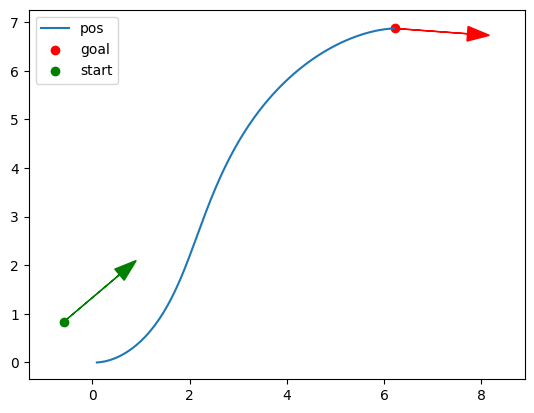

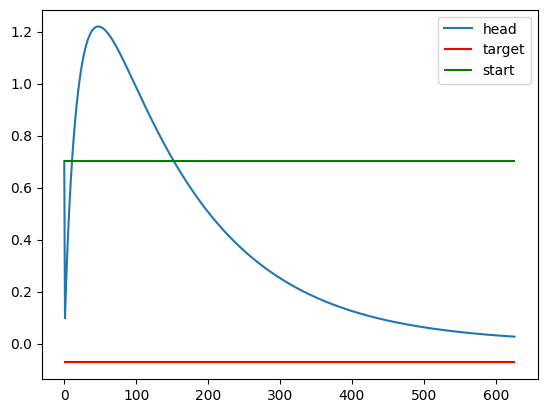

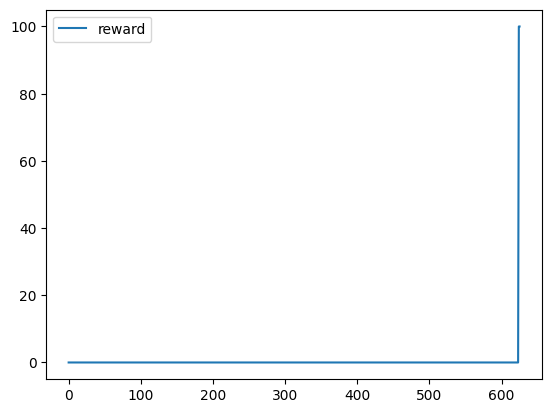

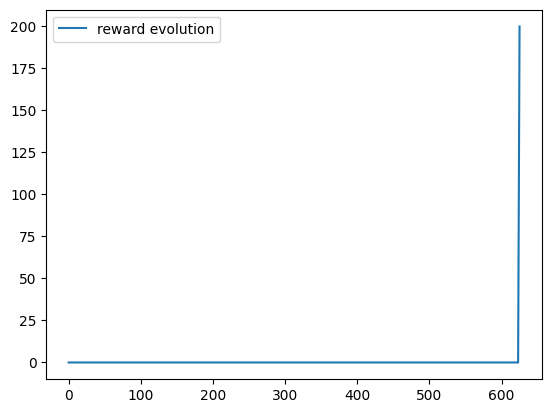

In [29]:
robot = Robot()
np.random.seed(np.random.randint(10))
envs = gym.make("gymnasium_env/ParkingTask-v0")
envs = gym.wrappers.RecordEpisodeStatistics(envs)
obs, info = envs.reset()
done = False
pos_traj = []
orientation_traj = [envs.unwrapped.start_config[2]]
rewards_episode = []
total_reward = 0
rewards_evolution = []
controller = Controller(k_rho=0.5, k_alpha=3, k_beta=-1.5)
envs.unwrapped.robot.max_speed = (1, 1)
while not done:
  dx = envs.unwrapped.target_config[0] - envs.unwrapped.robot.config[0]
  dy = envs.unwrapped.target_config[1] - envs.unwrapped.robot.config[1]

  rho, alpha, beta = envs.unwrapped.robot.cartesian2polar(dx, dy)
  alpha = normalize(alpha)
  beta = normalize(beta)
  v, omega = controller.get_cmds(rho, alpha, beta)

  action = (v, omega)
  next_obs, rew, terminated, truncated, info = envs.step(action)
  total_reward += rew
  pos_traj.append(envs.unwrapped.robot.config[:2].copy())
  orientation_traj.append(envs.unwrapped.robot.config[2].copy())
  done = terminated or truncated
  rewards_episode.append(rew)
  rewards_evolution.append(total_reward)

print(f"truncate: {truncated} terminate: {terminated} outbound: {envs.unwrapped.timeout} pos: {envs.unwrapped.robot.config}")
print(f"final time: {envs.unwrapped.time}")
print(f"episode_returns: {envs.episode_returns}")
print(f"episode_length: {envs.episode_lengths}")
import matplotlib.pyplot as plt

def plot_traj():


    plt.figure()
    x, y = zip(*pos_traj)
    plt.plot(x, y, label="pos")
    plt.scatter(envs.unwrapped.target_config[0], envs.unwrapped.target_config[1], c="r", label="goal")
    plt.scatter(envs.unwrapped.start_config[0], envs.unwrapped.start_config[1], c="g", label="start")

    dx_target, dy_target = np.cos(envs.unwrapped.target_config[2]), np.sin(envs.unwrapped.target_config[2])
    dx_start, dy_start = np.cos(envs.unwrapped.start_config[2]), np.sin(envs.unwrapped.start_config[2])
    length = 1.5
    width = 0.3

    plt.arrow(x=envs.unwrapped.target_config[0], y=envs.unwrapped.target_config[1],
              dx=length*dx_target, dy=length*dy_target, color="r", head_width=0.3)
    plt.arrow(x=envs.unwrapped.start_config[0], y=envs.unwrapped.start_config[1],
              dx=length*dx_start, dy=length*dy_start, color="g", head_width=0.3)

    plt.legend()
    plt.axis("equal")

    plt.figure()
    plt.plot(orientation_traj, label="head")
    plt.hlines(envs.unwrapped.target_config[2:], xmin=0, xmax=len(orientation_traj), colors=["r"], label="target")
    plt.hlines(envs.unwrapped.start_config[2:], xmin=0, xmax=len(orientation_traj), colors=["g"], label="start")
    plt.legend()

plot_traj()

plt.figure()
plt.plot(rewards_episode, label="reward")
plt.legend()

plt.figure()
plt.plot(rewards_evolution, label="reward evolution")
plt.legend()

In [ ]:
#
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

vec_env = make_vec_env("gymnasium_env/ParkingTask-v0", n_envs=128)

model = PPO("MlpPolicy", vec_env, verbose=1, n_steps=256, batch_size=256,
            tensorboard_log="./ppo_parkingtask_tensorboard/", ent_coef=0.016)

#model.load("./ppo_parking_task1")
model.learn(total_timesteps=5_000_000, tb_log_name="first_run")

ModuleNotFoundError: No module named 'stable_baselines3'

In [ ]:
model.save("./ppo_parking_task2")

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
truncate: True terminate: False outbound: (True, np.True_) pos: [12.98751338 28.99336284  2.30159993]
final time: 20.019999999999662
episode_returns: -2020.7902294694777
episode_length: 1001


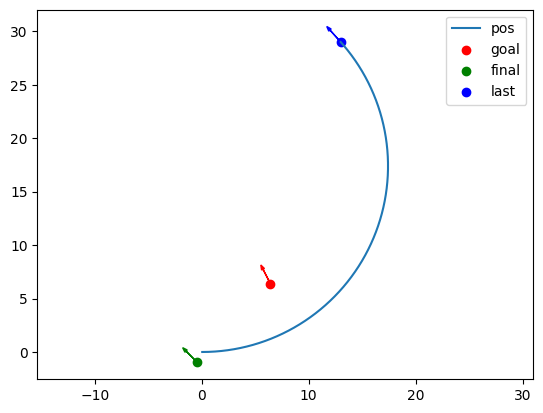

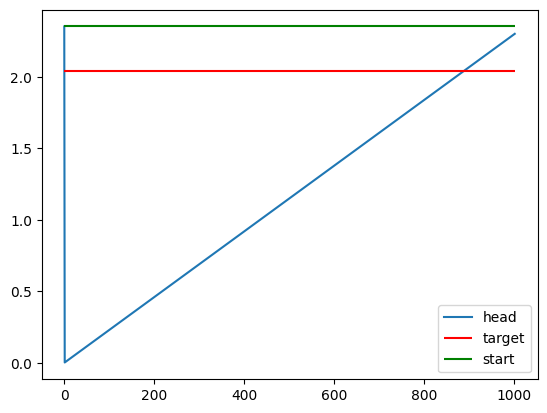

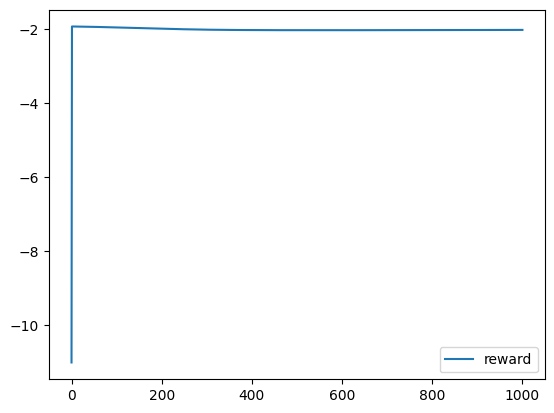

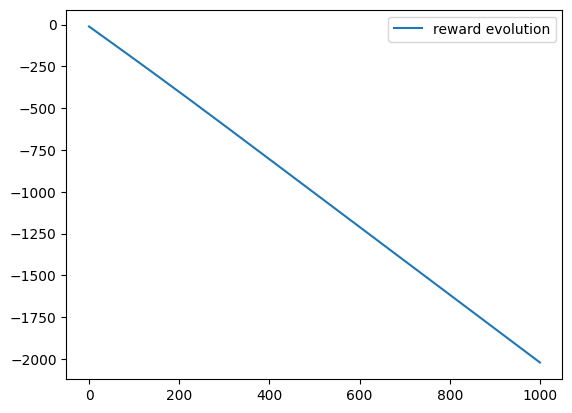

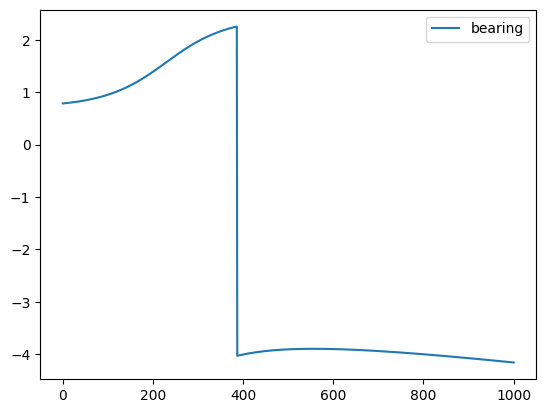

In [ ]:
#
"""
obs = vec_env.reset()
print(obs.shape)
for _ in range(100):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = vec_env.step(action)
    if terminated or truncated:
        obs = vec_env.reset()"""


robot = Robot()
envs = gym.make("gymnasium_env/ParkingTask-v0")
envs = gym.wrappers.RecordEpisodeStatistics(envs)
#envs.unwrapped.max_time_step = 30
model = PPO.load("./ppo_parking_task2", env=envs)
obs, info = envs.reset()
done = False
pos_traj = []
orientation_traj = [envs.unwrapped.robot.start_config[2]]
bearing_traj = []
rewards_episode = []
rewards_evolution = []
total_reward = 0

while not done:
  action, _ = model.predict(obs, deterministic=True)
  next_obs, rew, terminated, truncated, info = envs.step(action)
  total_reward += rew
  pos_traj.append(envs.unwrapped.robot.config[:2].copy())
  orientation_traj.append(envs.unwrapped.robot.config[2].copy())
  bearing_traj.append(envs.unwrapped.robot.bearing.copy())
  done = terminated or truncated
  rewards_episode.append(rew)
  rewards_evolution.append(total_reward)

print(f"truncate: {truncated} terminate: {terminated} outbound: {envs.unwrapped.timeout} pos: {envs.unwrapped.robot.config}")
print(f"final time: {envs.unwrapped.time}")
print(f"episode_returns: {envs.episode_returns}")
print(f"episode_length: {envs.episode_lengths}")


def plot_traj():


    plt.figure()
    x, y = zip(*pos_traj)
    plt.plot(x, y, label="pos")
    plt.scatter(envs.unwrapped.robot.target_config[0], envs.unwrapped.robot.target_config[1], c="r", label="goal")
    plt.scatter(envs.unwrapped.robot.start_config[0], envs.unwrapped.robot.start_config[1], c="g", label="final")
    plt.scatter(envs.unwrapped.robot.config[0], envs.unwrapped.robot.config[1], c="b", label="last")

    dx_target, dy_target = np.cos(envs.unwrapped.robot.target_config[2]), np.sin(envs.unwrapped.robot.target_config[2])
    dx_start, dy_start = np.cos(envs.unwrapped.robot.start_config[2]), np.sin(envs.unwrapped.robot.start_config[2])
    dx_final, dy_final = np.cos(envs.unwrapped.robot.config[2]), np.sin(envs.unwrapped.robot.config[2])
    length = 1.5
    width = 0.3

    plt.arrow(x=envs.unwrapped.robot.target_config[0], y=envs.unwrapped.robot.target_config[1],
              dx=length*dx_target, dy=length*dy_target, color="r", head_width=0.3)
    plt.arrow(x=envs.unwrapped.robot.start_config[0], y=envs.unwrapped.robot.start_config[1],
              dx=length*dx_start, dy=length*dy_start, color="g", head_width=0.3)

    plt.arrow(x=envs.unwrapped.robot.config[0], y=envs.unwrapped.robot.config[1],
              dx=length*dx_final, dy=length*dy_final, color="b", head_width=0.3)

    plt.legend()
    plt.axis("equal")

    plt.figure()
    plt.plot(orientation_traj, label="head")
    plt.hlines(envs.unwrapped.robot.target_config[2:], xmin=0, xmax=len(orientation_traj), colors=["r"], label="target")
    plt.hlines(envs.unwrapped.robot.start_config[2:], xmin=0, xmax=len(orientation_traj), colors=["g"], label="start")
    plt.legend()

plot_traj()

plt.figure()
plt.plot(rewards_episode, label="reward")
plt.legend()

plt.figure()
plt.plot(rewards_evolution, label="reward evolution")
plt.legend()

plt.figure()
plt.plot(bearing_traj, label="bearing")
plt.legend()

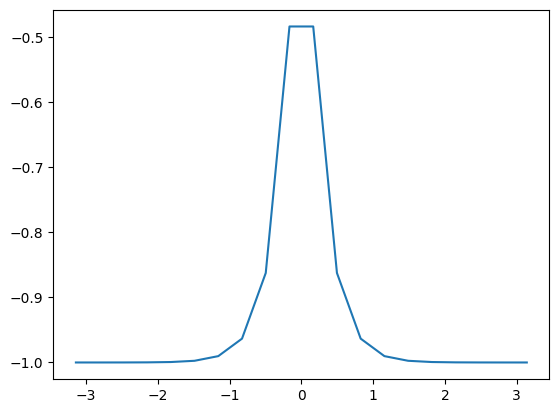

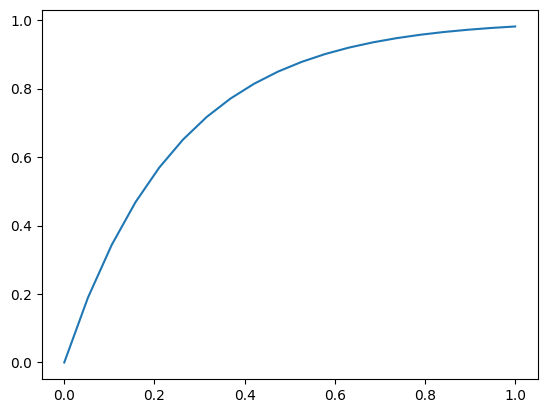

In [ ]:
import matplotlib.pyplot as plt
x = np.linspace(-np.pi, np.pi, 20)
y = np.exp(-4 * np.abs(x)) - 1
plt.figure()
plt.plot(x, y)
x = np.linspace(0, 1, 20)
y = 1-np.exp(-4 * np.abs(x))
plt.figure()
plt.plot(x, y)

In [ ]:
a = [*(3, 2)]
a

[3, 2]